In [20]:
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

K = 30  # time steps

t = np.linspace(0, 1, K)

# User motion
user_x = 50 + 700 * t
user_y = 300 + 10 * np.sin(2 * np.pi * t)

# Robot motion
robot_x = 80 + 680 * t
robot_y = 180 + 120 * np.exp(-3 * (t - 0.5) ** 2)


traj_in = np.stack(
    [
        np.stack([user_x, user_y], axis=-1),
        np.stack([robot_x, robot_y], axis=-1),
    ]
)
print(traj_in.shape)  # (2, 30, 2)

(2, 30, 2)


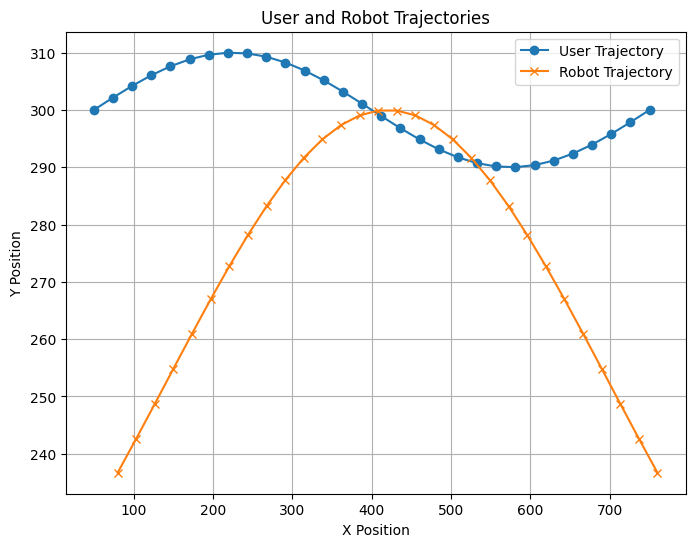

In [22]:
# Visualize the trajectories
plt.figure(figsize=(8, 6))
plt.plot(user_x, user_y, label="User Trajectory", marker="o")
plt.plot(robot_x, robot_y, label="Robot Trajectory", marker="x")
plt.title("User and Robot Trajectories")
plt.xlabel("X Position")
plt.ylabel("Y Position")
plt.legend()
plt.grid()
plt.show()

In [ ]:
from scipy.ndimage import gaussian_filter1d


def bundle_procedural(
    traj_in: np.ndarray,
    bundle_strength: float = 0.95,
    proximity_sigma: float = 25.0,
    smooth_sigma: float = 2.0,
) -> np.ndarray:
    """Bundle two trajectories toward their centreline when close.

    Args:
        traj_in: Shape (2, K, 2) — two input trajectories.
        bundle_strength: Maximum blending strength (0 to 1).
        proximity_sigma: Distance scale for proximity weighting.
        smooth_sigma: Gaussian smoothing for the centreline.

    Returns:
        bundled: Shape (2, K, 2) — bundled trajectories.
    """
    K = traj_in.shape[1]
    bundled = traj_in.copy()

    # Centreline: midpoint at each time step
    centreline = traj_in.mean(axis=0)  # (K, 2)

    # Smooth the centreline
    centreline[:, 0] = gaussian_filter1d(centreline[:, 0], sigma=smooth_sigma)
    centreline[:, 1] = gaussian_filter1d(centreline[:, 1], sigma=smooth_sigma)

    # Per-timestep distance between the two trajectories
    dist = np.linalg.norm(traj_in[0] - traj_in[1], axis=-1)  # (K,)

    # Weight: strong bundling when close, none when far
    # proximity_sigma=25 gives good discrimination: dist=16 -> w~0.8, dist=70 -> w~0.01
    weight = bundle_strength * np.exp(-(dist**2) / (2 * proximity_sigma**2))

    # Smooth the weights to avoid abrupt transitions
    weight = gaussian_filter1d(weight, sigma=1.5)

    # Pull each trajectory toward the centreline
    for i in range(2):
        bundled[i] = (1 - weight[:, None]) * traj_in[i] + weight[:, None] * centreline

    return bundled


bundled = bundle_procedural(traj_in)

In [ ]:
def add_offsets(bundled: np.ndarray, offset_pixels: float = 1.0) -> np.ndarray:
    """Add perpendicular offsets to bundled trajectories.

    Args:
        bundled: Shape (2, K, 2) — bundled trajectories.
        offset_pixels: Half the separation distance between the two objects.

    Returns:
        result: Shape (2, K, 2) — trajectories with offsets applied.
    """
    centreline = bundled.mean(axis=0)  # (K, 2)
    result = bundled.copy()

    # Centreline direction at each time step
    direction = np.gradient(centreline, axis=0)  # (K, 2)
    length = np.linalg.norm(direction, axis=-1, keepdims=True)
    length = np.maximum(length, 1e-6)
    direction = direction / length

    # Perpendicular: rotate 90 degrees
    normal = np.stack([-direction[:, 1], direction[:, 0]], axis=-1)  # (K, 2)

    # Offset object 0 to one side, object 1 to the other
    result[0] += offset_pixels * normal
    result[1] -= offset_pixels * normal

    return result


pos_procedural = add_offsets(bundled)

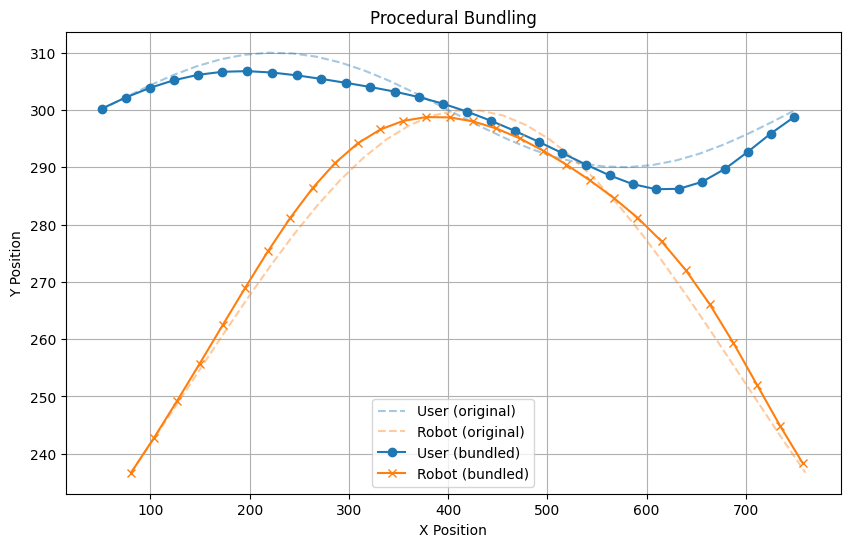

In [35]:
# Visualize pos_procedural vs original
plt.figure(figsize=(10, 6))
plt.plot(
    traj_in[0, :, 0],
    traj_in[0, :, 1],
    "--",
    alpha=0.4,
    color="C0",
    label="User (original)",
)
plt.plot(
    traj_in[1, :, 0],
    traj_in[1, :, 1],
    "--",
    alpha=0.4,
    color="C1",
    label="Robot (original)",
)
plt.plot(
    pos_procedural[0, :, 0],
    pos_procedural[0, :, 1],
    label="User (bundled)",
    marker="o",
    color="C0",
)
plt.plot(
    pos_procedural[1, :, 0],
    pos_procedural[1, :, 1],
    label="Robot (bundled)",
    marker="x",
    color="C1",
)
plt.title("Procedural Bundling")
plt.xlabel("X Position")
plt.ylabel("Y Position")
plt.legend()
plt.grid()
plt.show()

# Declarative Animation

In [ ]:
import jax
import jax.numpy as jnp
import optax
from stljax.formula import Predicate, Always, Eventually

K = 30
N = 2

# Convert input trajectories to JAX array: shape (K, N, 2)
traj_jax = jnp.array(traj_in.transpose(1, 0, 2), dtype=jnp.float32)


def compute_distance(pos):
    """Compute per-timestep distance between the two objects.

    Args:
        pos: Shape (K, 2, 2) — positions over time.

    Returns:
        Shape (K,) — distance at each time step.
    """
    diff = pos[:, 0, :] - pos[:, 1, :]
    return jnp.sqrt((diff**2).sum(axis=-1) + 1e-6)


# --- STL Specifications ---
d_pred = Predicate("d", lambda d: d)

# Bundling: during the middle portion (t=10..22), stay within 15 pixels
phi_bundle = Always(d_pred <= 15.0, interval=[10, 22])

# Visibility: always at least 5 pixels apart (so they don't overlap)
phi_visible = Always(d_pred >= 5.0)

In [ ]:
def total_loss(pos):
    """Combined loss: STL robustness + smoothness + deviation.

    Args:
        pos: Shape (K, 2, 2) — decision variable.

    Returns:
        Scalar loss.
    """
    dist = compute_distance(pos)

    # STL robustness (maximize → negate for minimization)
    rob_bundle = phi_bundle(dist)[0]
    rob_visible = phi_visible(dist)[0]
    stl_loss = -(rob_bundle + rob_visible)

    # Direct proximity loss: pull trajectories together in the bundle interval
    # This provides per-timestep gradients (unlike STL min which only flows through one)
    bundle_dist = dist[10:23]
    proximity_loss = jnp.sum(jnp.maximum(bundle_dist - 10.0, 0.0) ** 2)

    # Smoothness: penalize large accelerations
    velocity = jnp.diff(pos, axis=0)  # (K-1, 2, 2)
    acceleration = jnp.diff(velocity, axis=0)  # (K-2, 2, 2)
    smooth_loss = (acceleration**2).sum()

    # Deviation: stay close to the original trajectories (very light)
    deviation_loss = ((pos - traj_jax) ** 2).sum()

    # Anchor only the first and last timestep
    anchor_loss = ((pos[0] - traj_jax[0]) ** 2).sum() + (
        (pos[-1] - traj_jax[-1]) ** 2
    ).sum()

    return (
        100.0 * stl_loss
        + 1.0 * proximity_loss
        + 0.005 * smooth_loss
        + 0.0001 * deviation_loss
        + 50.0 * anchor_loss
    )

In [36]:
optimizer = optax.adam(learning_rate=0.5)


@jax.jit
def optimize(pos, opt_state, n_steps=2000):
    """Run n_steps of Adam optimization."""

    def step(carry, _):
        pos, opt_state = carry
        loss, grads = jax.value_and_grad(total_loss)(pos)
        updates, opt_state = optimizer.update(grads, opt_state, pos)
        pos = optax.apply_updates(pos, updates)
        return (pos, opt_state), loss

    (pos_opt, opt_state), losses = jax.lax.scan(
        step, (pos, opt_state), None, length=n_steps
    )
    return pos_opt, losses


# Initialize from the raw trajectories
pos_init = traj_jax.copy()
opt_state = optimizer.init(pos_init)

pos_opt, losses = optimize(pos_init, opt_state)
print(f"Final loss: {losses[-1]:.4f}")

Final loss: -924.0767


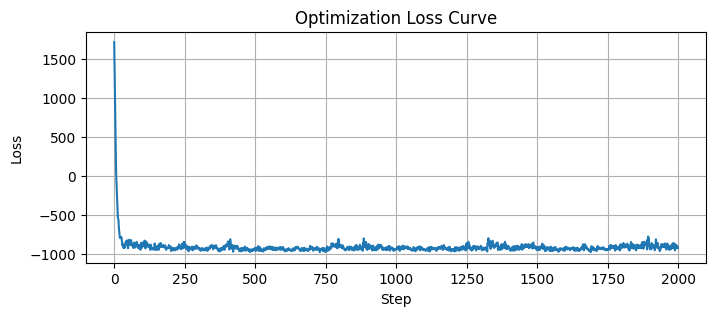

In [ ]:
# Plot loss curve
plt.figure(figsize=(8, 3))
plt.plot(np.array(losses))
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Optimization Loss Curve")
plt.grid()
plt.show()

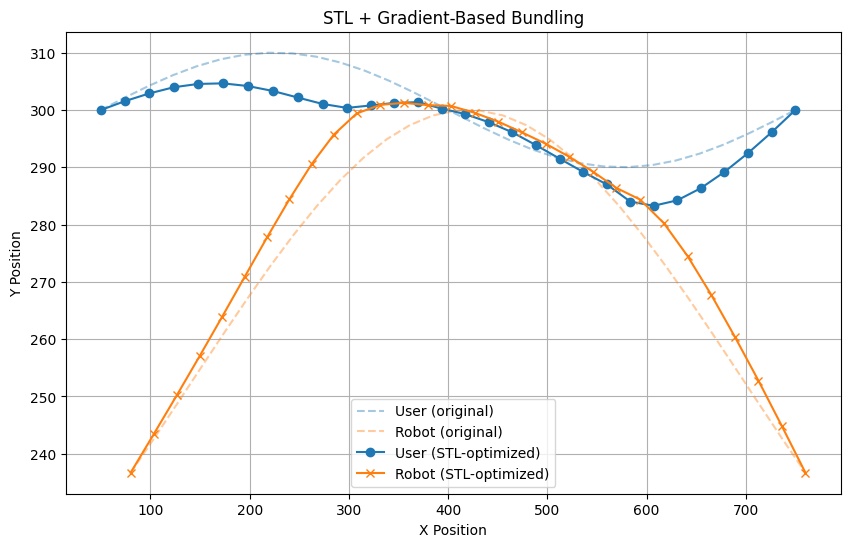

Distances (STL-optimized):
  t= 0: 70.1
  t= 1: 64.9
  t= 2: 59.5
  t= 3: 53.7
  t= 4: 47.3
  t= 5: 40.4
  t= 6: 33.0
  t= 7: 25.5
  t= 8: 18.3
  t= 9: 12.6
  t=10: 9.8 <-- bundled
  t=11: 10.0 <-- bundled
  t=12: 9.7 <-- bundled
  t=13: 9.9 <-- bundled
  t=14: 9.5 <-- bundled
  t=15: 9.9 <-- bundled
  t=16: 9.7 <-- bundled
  t=17: 9.8 <-- bundled
  t=18: 9.8 <-- bundled
  t=19: 9.8 <-- bundled
  t=20: 9.8 <-- bundled
  t=21: 9.4 <-- bundled
  t=22: 10.1 <-- bundled
  t=23: 10.9
  t=24: 14.2
  t=25: 21.3
  t=26: 30.6
  t=27: 41.1
  t=28: 52.3
  t=29: 64.1


In [38]:
# Visualize STL-optimized trajectories vs original
pos_opt_np = np.array(pos_opt)
plt.figure(figsize=(10, 6))
plt.plot(
    traj_in[0, :, 0],
    traj_in[0, :, 1],
    "--",
    alpha=0.4,
    color="C0",
    label="User (original)",
)
plt.plot(
    traj_in[1, :, 0],
    traj_in[1, :, 1],
    "--",
    alpha=0.4,
    color="C1",
    label="Robot (original)",
)
plt.plot(
    pos_opt_np[:, 0, 0],
    pos_opt_np[:, 0, 1],
    label="User (STL-optimized)",
    marker="o",
    color="C0",
)
plt.plot(
    pos_opt_np[:, 1, 0],
    pos_opt_np[:, 1, 1],
    label="Robot (STL-optimized)",
    marker="x",
    color="C1",
)
plt.title("STL + Gradient-Based Bundling")
plt.xlabel("X Position")
plt.ylabel("Y Position")
plt.legend()
plt.grid()
plt.show()

# Print distances to verify bundling
opt_dist = np.linalg.norm(pos_opt_np[:, 0] - pos_opt_np[:, 1], axis=-1)
print("Distances (STL-optimized):")
for i in range(K):
    marker = " <-- bundled" if 10 <= i <= 22 else ""
    print(f"  t={i:2d}: {opt_dist[i]:.1f}{marker}")